#Submission 2 - Sistem Rekomendasi

Nama : Ainun Annisa K

Dataset : [Book Recommendation Dataset](https://www.kaggle.com/datasets/arashnic/book-recommendation-dataset/data)

Import Library

In [1]:
from google.colab import files
import zipfile
import io
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, precision_score, recall_score
from math import sqrt

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Flatten, Concatenate, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras import layers, regularizers

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Dataset.zip to Dataset.zip


In [3]:
zip_file_name = next(iter(uploaded))

with zipfile.ZipFile(io.BytesIO(uploaded[zip_file_name]), 'r') as zip_ref:
    zip_ref.extractall("/content")

In [4]:
books = pd.read_csv('/content/Dataset/Books.csv')
ratings = pd.read_csv('/content/Dataset/Ratings.csv')
users = pd.read_csv('/content/Dataset/Users.csv')

<ipython-input-4-2b60d2dd4244>:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  books = pd.read_csv('/content/Dataset/Books.csv')


### Data Understanding

In [5]:
books.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [6]:
print("Number of Book ISBN numbers:", len(books['ISBN'].unique()))
print("Number of book titles:", len(books['Book-Title'].unique()))
print('Number of book authors:', len(books['Book-Author'].unique()))
print('Number of Publication Years:', len(books['Year-Of-Publication'].unique()))
print('Number of publisher names:', len(books['Publisher'].unique()))

Number of Book ISBN numbers: 271360
Number of book titles: 242135
Number of book authors: 102024
Number of Publication Years: 202
Number of publisher names: 16808


Berdasarkan dataframe books, jumlah judul buku dalam dataset adalah 242.135, sedangkan jumlah ISBN buku adalah 271.357. Hal ini menunjukkan adanya beberapa buku yang tidak memiliki nomor ISBN karena seharusnya setiap buku memiliki ISBN yang unik. Dalam hal ini, dataset akan difilter untuk memastikan setiap buku memiliki ISBN yang unik.

In [7]:
ratings.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [8]:
users.head()

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


Penerbit dengan buku terbanyak

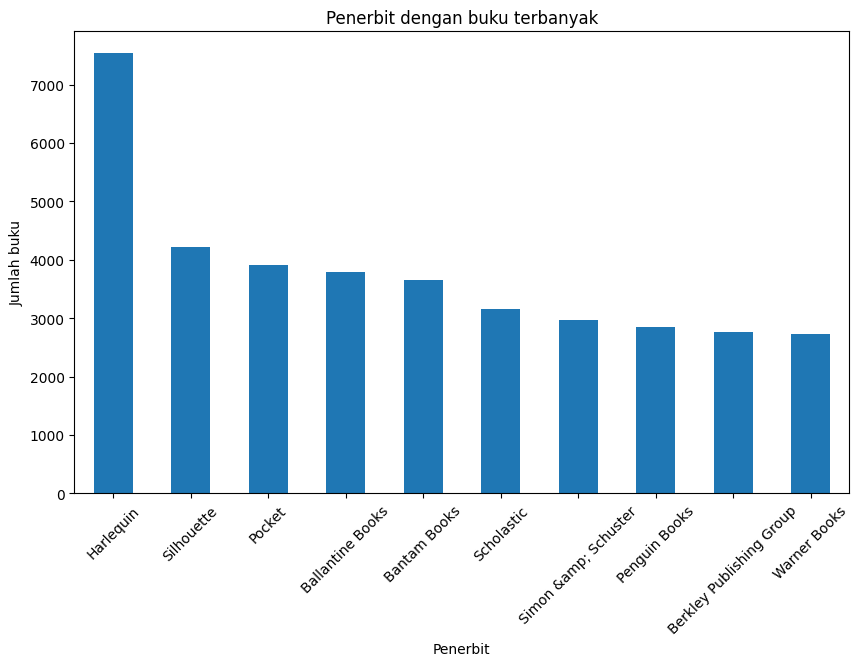

In [9]:
top_publishers = books['Publisher'].value_counts().head(10)

plt.figure(figsize=(10, 6))
top_publishers.plot(kind='bar')
plt.title('Penerbit dengan buku terbanyak')
plt.xlabel('Penerbit')
plt.ylabel('Jumlah buku')
plt.xticks(rotation=45)
plt.show()


Berdasarkan informasi di atas, diketahui bahwa penerbit Harlequin merilis buku paling banyak, dengan total lebih dari 7000 buku.

Penulis dengan buku terbanyak

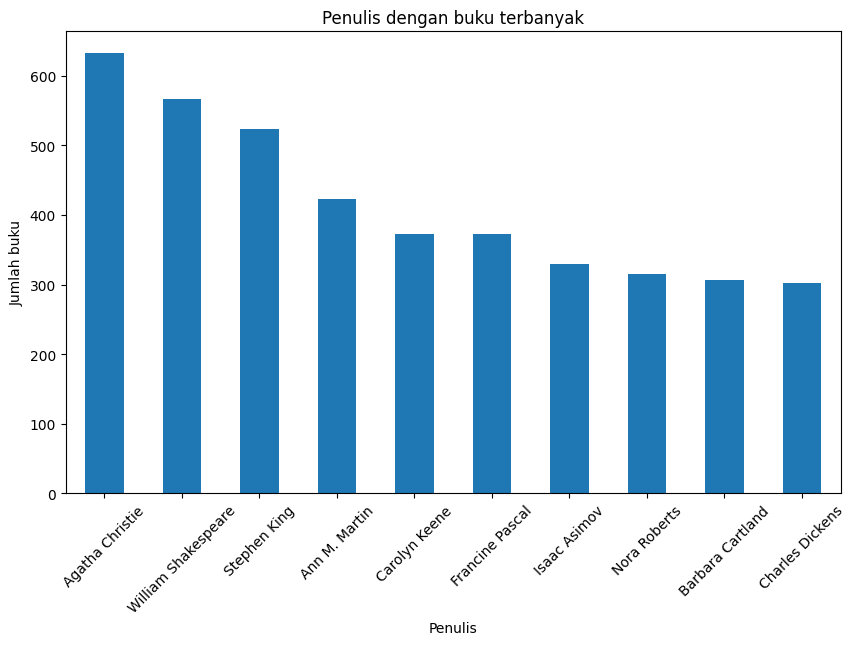

In [10]:
top_authors = books['Book-Author'].value_counts().head(10)

plt.figure(figsize=(10, 6))
top_authors.plot(kind='bar')
plt.title('Penulis dengan buku terbanyak')
plt.xlabel('Penulis')
plt.ylabel('Jumlah buku')
plt.xticks(rotation=45)
plt.show()


Berdasarkan informasi di atas, diketahui bahwa penulis dengan nama Agatha Christie menulis buku paling banyak, dengan total lebih dari 600 buku. Dari informasi ini, juga terlihat bahwa dataset ini mencakup beberapa penulis yang telah menulis lebih dari satu judul buku.

Penulis dengan rata-rata rating tertinggi

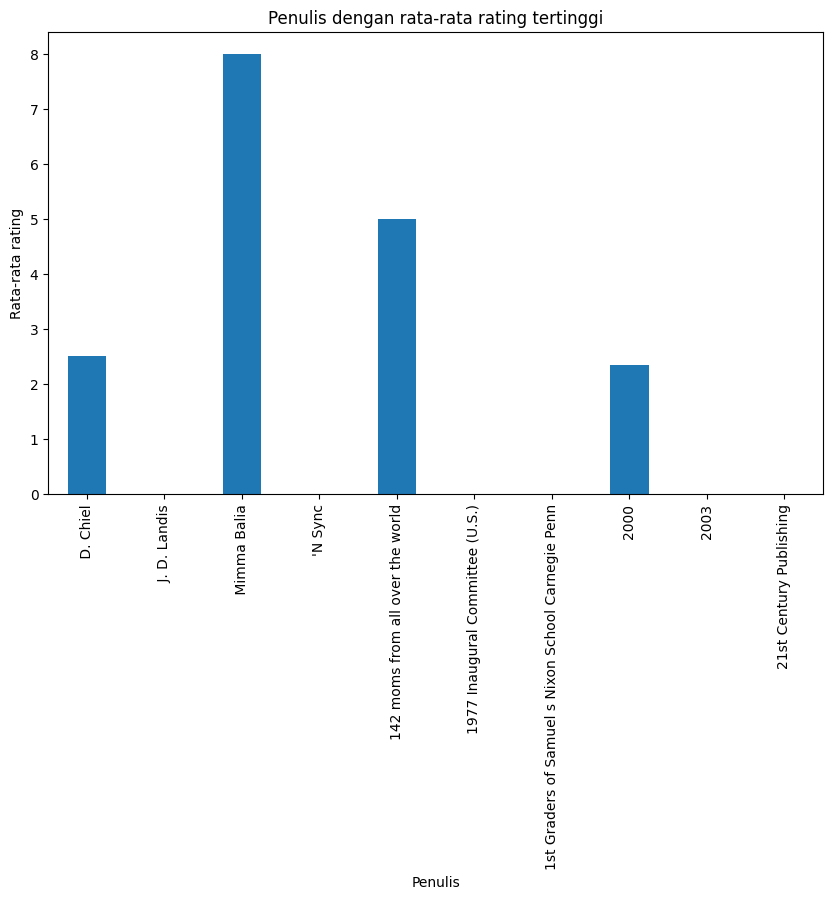

In [17]:
avg_rating_per_author = ratings.merge(books[['ISBN', 'Book-Author']], on='ISBN').groupby('Book-Author')['Book-Rating'].mean()
plt.figure(figsize=(10, 6))
avg_rating_per_author[:10].plot(kind='bar')
plt.title('Penulis dengan rata-rata rating tertinggi')
plt.xlabel('Penulis')
plt.ylabel('Rata-rata rating')
plt.xticks(rotation=90 )
plt.show()

Dari plot diatas bisa dilihat bahwa terdapat perbedaan yang cukup besar dari rata-rata rating penulis.

Kota dan negara dengan user terbanyak

<ipython-input-25-3db1f755c9fe>:8: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90,horizontalalignment='center')


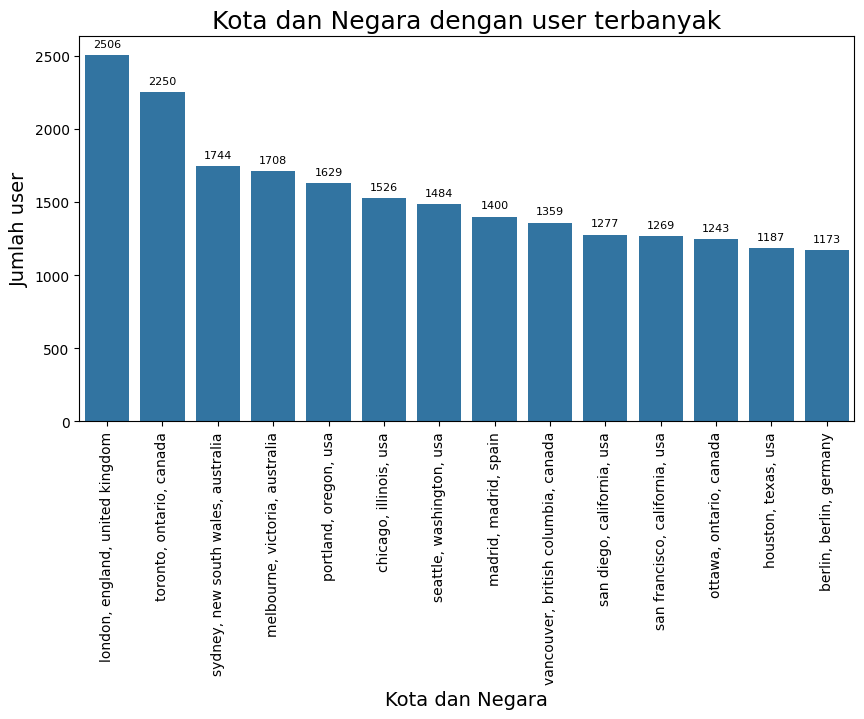

In [25]:
my_dict=(users['Location'].value_counts()).to_dict()
count= pd.DataFrame(list(my_dict.items()),columns = ['c','count'])
f = count.sort_values(by=['count'], ascending = False)
f = f.head(15)
f.drop(7,inplace=True)
fig=plt.figure(figsize=(10,5))
ax = sns.barplot(y = 'count',x= 'c' , data = f)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90,horizontalalignment='center')
for bar in ax.patches:
    ax.annotate(format(bar.get_height(), '.0f'),
                   (bar.get_x() + bar.get_width() / 2,
                    bar.get_height()), ha='center', va='center',
                   size=8, xytext=(0,8),
                   textcoords='offset points')
plt.xlabel("Kota dan Negara", size=14)
plt.ylabel("Jumlah user", size=14)
plt.title("Kota dan Negara dengan user terbanyak", size=18)
plt.show()

Dapat dilihat pada plot diatas bahwa negara dengan user terbanyak adalah pada kota London di United Kingdom dan diikuti oleh kota Toronto di Canada.

## Data Preparation

In [9]:
# Penghapusan 'Image-URL-S', 'Image-URL-M', 'Image-URL-L'

books.drop(labels=['Image-URL-S', 'Image-URL-M', 'Image-URL-L'], axis=1, inplace=True)

books.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company


In [10]:
# Menggabungkan dataframe books dan ratings berdasarkan ISBN

books = pd.merge(ratings, books, on='ISBN', how='left')
books.head()

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher
0,276725,034545104X,0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books
1,276726,0155061224,5,Rites of Passage,Judith Rae,2001,Heinle
2,276727,0446520802,0,The Notebook,Nicholas Sparks,1996,Warner Books
3,276729,052165615X,3,Help!: Level 1,Philip Prowse,1999,Cambridge University Press
4,276729,0521795028,6,The Amsterdam Connection : Level 4 (Cambridge ...,Sue Leather,2001,Cambridge University Press


In [11]:
#Cek missing values
books.isnull().sum()

User-ID                     0
ISBN                        0
Book-Rating                 0
Book-Title             118644
Book-Author            118645
Year-Of-Publication    118644
Publisher              118646
dtype: int64

In [12]:
# Menghapus missing values
books=books.dropna()

In [13]:
# Mengurutkan data berdasarkan ISBN
books= books.sort_values('ISBN', ascending=True)
books

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher
703628,171118,0000913154,8,The Way Things Work: An Illustrated Encycloped...,C. van Amerongen (translator),1967,Simon &amp; Schuster
866078,209516,0001010565,0,Mog's Christmas,Judith Kerr,1992,Collins
357256,86123,0001010565,0,Mog's Christmas,Judith Kerr,1992,Collins
103677,23902,0001046438,9,Liar,Stephen Fry,0,Harpercollins Uk
807953,196149,0001046713,0,Twopence to Cross the Mersey,Helen Forrester,1992,HarperCollins Publishers
...,...,...,...,...,...,...,...
1100731,264317,B000234N76,0,Falling Angels,Tracy Chevalier,2001,E P Dutton
423108,100906,B000234NC6,0,It Must've Been Something I Ate: The Return of...,Jeffrey Steingarten,2002,Knopf
419279,100088,B00029DGGO,0,"Good Wife Strikes Back, The",Elizabeth Buchan,0,Viking Adult
743545,179791,B0002JV9PY,0,The Blockade Runners,Jules Verne,0,Digireads.com


In [14]:
books.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1031133 entries, 703628 to 743546
Data columns (total 7 columns):
 #   Column               Non-Null Count    Dtype 
---  ------               --------------    ----- 
 0   User-ID              1031133 non-null  int64 
 1   ISBN                 1031133 non-null  object
 2   Book-Rating          1031133 non-null  int64 
 3   Book-Title           1031133 non-null  object
 4   Book-Author          1031133 non-null  object
 5   Year-Of-Publication  1031133 non-null  object
 6   Publisher            1031133 non-null  object
dtypes: int64(2), object(5)
memory usage: 62.9+ MB


In [15]:
#Cek duplicated ISBN
books.duplicated('ISBN').sum()

760985

In [44]:
# Menghapus data duplikat ISBN
books_new= books.drop_duplicates('ISBN')
books_new

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher
703628,171118,0000913154,8,The Way Things Work: An Illustrated Encycloped...,C. van Amerongen (translator),1967,Simon &amp; Schuster
866078,209516,0001010565,0,Mog's Christmas,Judith Kerr,1992,Collins
103677,23902,0001046438,9,Liar,Stephen Fry,0,Harpercollins Uk
807953,196149,0001046713,0,Twopence to Cross the Mersey,Helen Forrester,1992,HarperCollins Publishers
103678,23902,000104687X,6,"T.S. Eliot Reading \The Wasteland\"" and Other ...",T.S. Eliot,1993,HarperCollins Publishers
...,...,...,...,...,...,...,...
1100731,264317,B000234N76,0,Falling Angels,Tracy Chevalier,2001,E P Dutton
423108,100906,B000234NC6,0,It Must've Been Something I Ate: The Return of...,Jeffrey Steingarten,2002,Knopf
419279,100088,B00029DGGO,0,"Good Wife Strikes Back, The",Elizabeth Buchan,0,Viking Adult
743545,179791,B0002JV9PY,0,The Blockade Runners,Jules Verne,0,Digireads.com


## Modeling and Result

## Content Based Filtering

In [79]:
books_cb = books_new[:1000]

In [80]:
books_cb

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher
703628,171118,0000913154,8,The Way Things Work: An Illustrated Encycloped...,C. van Amerongen (translator),1967,Simon &amp; Schuster
866078,209516,0001010565,0,Mog's Christmas,Judith Kerr,1992,Collins
103677,23902,0001046438,9,Liar,Stephen Fry,0,Harpercollins Uk
807953,196149,0001046713,0,Twopence to Cross the Mersey,Helen Forrester,1992,HarperCollins Publishers
103678,23902,000104687X,6,"T.S. Eliot Reading \The Wasteland\"" and Other ...",T.S. Eliot,1993,HarperCollins Publishers
...,...,...,...,...,...,...,...
91851,20446,0006752225,0,City Hospital: Stress (City Hospital),Keith Miles,1996,HarperCollins Publishers
81707,16943,000675239X,0,The X-Files 4: Squeeze (The X-files),Ellen Steiber,1996,HarperCollins Publishers
625919,151806,0006754376,0,...and Conflict (Sugar Secrets S.),Mel Sparke,2000,Collins
547075,131221,0006754864,0,Flying High (Angels Unlimited S.),Annie Dalton,2001,Collins


In [81]:
vectorizer = CountVectorizer()
author_vector = vectorizer.fit_transform(books_cb['Book-Author'])

# Menghitung cosine similarity antar buku berdasarkan "Book-Author"
cosine_sim_author = cosine_similarity(author_vector)

In [82]:
def content_based_recommendation(book_title, similarity_matrix, items_df, top_k=5):
    index = np.where(items_df['Book-Title'] == book_title)[0]

    if index:
        index = index[0]

        # Hitung similarity dengan buku lain
        similar_books = sorted(list(enumerate(similarity_matrix[index])), key=lambda x: x[1], reverse=True)[1:(top_k + 1)]
        similar_books_indices = [i[0] for i in similar_books]
        recommended_books = items_df.iloc[similar_books_indices][['Book-Title', 'Book-Author']].drop_duplicates('Book-Title')

        return recommended_books.values.tolist()

    else:
        print(f"Buku dengan judul '{book_title}' tidak ditemukan dalam dataframe.")
        return None

In [83]:
book_title_to_recommend = "Paddington in the Kitchen"
recommendations = content_based_recommendation(book_title_to_recommend, cosine_sim_author, books_new)

if recommendations:
    df_recommendations = pd.DataFrame(recommendations, columns=['Recommended Book', 'Author'])
    print(f"Rekomendasi untuk buku '{book_title_to_recommend}':")
    print(df_recommendations)
else:
    print(f"Tidak ada rekomendasi untuk buku '{book_title_to_recommend}'.")

Rekomendasi untuk buku 'Paddington in the Kitchen':
                                    Recommended Book        Author
0                          Paddington in the Kitchen  Michael Bond
1  Paddington and the Marmalade Maze (Paddington ...  Michael Bond
2  Paddington at the Tower (A Paddington Picture ...  Michael Bond
3                       The Adventures of Paddington  Michael Bond
4  PADDINGTON GOES TO SALES L/CUB (Collins Colour...  Michael Bond


In [84]:
df_recommendations

,Recommended Book,Author
0,Paddington in the Kitchen,Michael Bond
1,Paddington and the Marmalade Maze (Paddington ...,Michael Bond
2,Paddington at the Tower (A Paddington Picture ...,Michael Bond
3,The Adventures of Paddington,Michael Bond
4,PADDINGTON GOES TO SALES L/CUB (Collins Colour...,Michael Bond


## Collaborative Filtering

In [45]:
# Convert kolom data menjadi list
isbn_id = books_new['ISBN'].tolist()
book_title = books_new['Book-Title'].tolist()
book_author = books_new['Book-Author'].tolist()
year_of_publication = books_new['Year-Of-Publication'].tolist()
publisher = books_new['Publisher'].tolist()

print(len(isbn_id))
print(len(book_title))
print(len(book_author))
print(len(year_of_publication))
print(len(publisher))

270148
270148
270148
270148
270148


In [46]:
books_cf = pd.DataFrame({
    'isbn': isbn_id,
    'book_title': book_title,
    'book_author': book_author,
    'year_of_publication': year_of_publication,
    'publisher': publisher

})

books_cf

,isbn,book_title,book_author,year_of_publication,publisher
0,0000913154,The Way Things Work: An Illustrated Encycloped...,C. van Amerongen (translator),1967,Simon &amp; Schuster
1,0001010565,Mog's Christmas,Judith Kerr,1992,Collins
2,0001046438,Liar,Stephen Fry,0,Harpercollins Uk
3,0001046713,Twopence to Cross the Mersey,Helen Forrester,1992,HarperCollins Publishers
4,000104687X,"T.S. Eliot Reading \The Wasteland\"" and Other ...",T.S. Eliot,1993,HarperCollins Publishers
...,...,...,...,...,...
270143,B000234N76,Falling Angels,Tracy Chevalier,2001,E P Dutton
270144,B000234NC6,It Must've Been Something I Ate: The Return of...,Jeffrey Steingarten,2002,Knopf
270145,B00029DGGO,"Good Wife Strikes Back, The",Elizabeth Buchan,0,Viking Adult
270146,B0002JV9PY,The Blockade Runners,Jules Verne,0,Digireads.com


In [47]:
books_cf = books_cf[:20000]
books_cf

,isbn,book_title,book_author,year_of_publication,publisher
0,0000913154,The Way Things Work: An Illustrated Encycloped...,C. van Amerongen (translator),1967,Simon &amp; Schuster
1,0001010565,Mog's Christmas,Judith Kerr,1992,Collins
2,0001046438,Liar,Stephen Fry,0,Harpercollins Uk
3,0001046713,Twopence to Cross the Mersey,Helen Forrester,1992,HarperCollins Publishers
4,000104687X,"T.S. Eliot Reading \The Wasteland\"" and Other ...",T.S. Eliot,1993,HarperCollins Publishers
...,...,...,...,...,...
19995,0140444696,The Kreutzer Sonata and Other Stories (Penguin...,Leo Tolstoy,1986,Penguin Books
19996,014044470X,The Fiancee and Other Stories (Penguin Classics),Anton Pavlovich Chekhov,1986,Penguin Books
19997,0140444726,Jacques the Fatalist and His Master (Penguin C...,Denis Diderot,1986,Penguin Books
19998,0140444742,Seven Viking Romances (Penguin Classics),Hermann Palsson,1986,Penguin Books


In [48]:
x=books.groupby('User-ID').count()['Book-Rating']>200
x.sum()

811

In [49]:
users_200=x[x].index
users_200

Int64Index([   254,   2276,   2766,   2977,   3363,   4017,   4385,   6251,
              6323,   6543,
            ...
            271705, 273979, 274004, 274061, 274301, 274308, 275970, 277427,
            277639, 278418],
           dtype='int64', name='User-ID', length=811)

In [50]:
filtered_rating=books[books['User-ID'].isin(users_200)]
filtered_rating

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher
703628,171118,0000913154,8,The Way Things Work: An Illustrated Encycloped...,C. van Amerongen (translator),1967,Simon &amp; Schuster
866078,209516,0001010565,0,Mog's Christmas,Judith Kerr,1992,Collins
103677,23902,0001046438,9,Liar,Stephen Fry,0,Harpercollins Uk
103678,23902,000104687X,6,"T.S. Eliot Reading \The Wasteland\"" and Other ...",T.S. Eliot,1993,HarperCollins Publishers
103679,23902,0001047213,9,The Fighting Man,Gerald Seymour,1993,HarperCollins Publishers
...,...,...,...,...,...,...,...
613350,148258,B0001I1KOG,10,New York Public Library Literature Companion,New York Public Library,2001,Free Press
1133070,271705,B0001PIOX4,0,Fahrenheit 451,Ray Bradbury,1993,Simon &amp; Schuster
423107,100906,B000234N3A,9,Fraud,David Rakoff,2001,Doubleday
1100731,264317,B000234N76,0,Falling Angels,Tracy Chevalier,2001,E P Dutton


In [51]:
y=filtered_rating.groupby('Book-Title').count()['Book-Rating']>=50
famous_books=y[y].index

In [52]:
final_rating=filtered_rating[filtered_rating['Book-Title'].isin(famous_books)]
final_rating

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher
103680,23902,0001047973,9,Brave New World,Aldous Huxley,1999,Trafalgar Square Publishing
457420,110029,0006177379,0,Secrets,Vera Cowie,1990,HarperCollins Publishers
618498,149907,0020697406,0,The Lost World,Randall Jarrell,1985,Simon &amp; Schuster
549535,131837,002542730X,0,Politically Correct Bedtime Stories: Modern Ta...,James Finn Garner,1994,John Wiley &amp; Sons Inc
719594,174216,002542730X,5,Politically Correct Bedtime Stories: Modern Ta...,James Finn Garner,1994,John Wiley &amp; Sons Inc
...,...,...,...,...,...,...,...
1140656,274301,B00009NDAN,10,Winter Solstice,Rosamunde Pilcher,2000,St. Martin's Press
468744,112001,B0000T6KHI,10,Three Fates,Nora Roberts,2002,Putnam Pub Group
294252,69697,B0000T6KHI,0,Three Fates,Nora Roberts,2002,Putnam Pub Group
1133070,271705,B0001PIOX4,0,Fahrenheit 451,Ray Bradbury,1993,Simon &amp; Schuster


In [53]:
final_rating.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 58586 entries, 103680 to 1100731
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   User-ID              58586 non-null  int64 
 1   ISBN                 58586 non-null  object
 2   Book-Rating          58586 non-null  int64 
 3   Book-Title           58586 non-null  object
 4   Book-Author          58586 non-null  object
 5   Year-Of-Publication  58586 non-null  object
 6   Publisher            58586 non-null  object
dtypes: int64(2), object(5)
memory usage: 3.6+ MB


In [54]:
# Mengubah User-ID menjadi list
user_ids = final_rating['User-ID'].unique().tolist()
print('list userIDs: ', user_ids)

# Mengubah User-ID encoding
user_to_user_encoded = {x: i for i, x in enumerate(user_ids)}
print('encoded userID: ', user_to_user_encoded)

user_encoded_to_user = {i: x for i, x in enumerate(user_ids)}
print('encoded number to userID: ', user_encoded_to_user)

list userIDs:  [23902, 110029, 149907, 131837, 174216, 201526, 211426, 86243, 265313, 155147, 126604, 250405, 185233, 204864, 178667, 41084, 111947, 44728, 179733, 88733, 250962, 26535, 12538, 243077, 266865, 235842, 31826, 13552, 24194, 30533, 225763, 238120, 110934, 183995, 209516, 165308, 200226, 112026, 229741, 198711, 228998, 51883, 170518, 113270, 150979, 43246, 230249, 277427, 130474, 173291, 3363, 28204, 25981, 81045, 128835, 77809, 60244, 71712, 174304, 172030, 82407, 82831, 55548, 266226, 128696, 271705, 269566, 173415, 159858, 188010, 208671, 196077, 184299, 52584, 11676, 190807, 264317, 119575, 258938, 80538, 16795, 36836, 46398, 181687, 23768, 256167, 140000, 98741, 137589, 51350, 226545, 217375, 262399, 265115, 32440, 235392, 167800, 125519, 265889, 105979, 125774, 106225, 75860, 205980, 109955, 238781, 251844, 246513, 102967, 247447, 31315, 244688, 135149, 78553, 234623, 175003, 87746, 149934, 37567, 36609, 254465, 266056, 229011, 270820, 131046, 168144, 78783, 131402, 1

In [55]:
# Mengubah ISBN menjadi list
isbn_id = final_rating['ISBN'].unique().tolist()

# Mengubah ISBN encoding
isbn_to_isbn_encoded = {x: i for i, x in enumerate(isbn_id)}
isbn_encoded_to_isbn = {i: x for i, x in enumerate(isbn_id)}

In [56]:
final_rating['user'] = final_rating['User-ID'].map(user_to_user_encoded)
final_rating['book_title'] = final_rating['ISBN'].map(isbn_to_isbn_encoded)

<ipython-input-56-a80d4d235a6e>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_rating['user'] = final_rating['User-ID'].map(user_to_user_encoded)
<ipython-input-56-a80d4d235a6e>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_rating['book_title'] = final_rating['ISBN'].map(isbn_to_isbn_encoded)


In [57]:
# Menghitung jumlah pengguna dan buku
num_users = len(user_to_user_encoded)
print(num_users)

num_book_title = len(isbn_to_isbn_encoded)
print(num_book_title)

810
2136


In [58]:
final_rating['Book-Rating'] = final_rating['Book-Rating'].values.astype(np.float32)

# Menentukan nilai minimum dan maximum rating buku
min_rating = min(final_rating['Book-Rating'])
max_rating = max(final_rating['Book-Rating'])

print('Number of Users: {}, Number of Books: {}, Min Rating: {}, Max Rating: {}'.format(
     num_users, num_book_title, min_rating, max_rating
))

Number of Users: 810, Number of Books: 2136, Min Rating: 0.0, Max Rating: 10.0


<ipython-input-58-f733194fe3c8>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_rating['Book-Rating'] = final_rating['Book-Rating'].values.astype(np.float32)


In [59]:
class RecommenderNet(tf.keras.Model):
    def __init__(self, num_users, num_book_titles, embedding_size, dropout_rate=0.2, **kwargs):
        super(RecommenderNet, self).__init__(**kwargs)
        self.num_users = num_users
        self.num_book_titles = num_book_titles
        self.embedding_size = embedding_size
        self.dropout_rate = dropout_rate

        self.user_embedding = layers.Embedding(
            num_users,
            embedding_size,
            embeddings_initializer='he_normal',
            embeddings_regularizer=regularizers.l2(1e-6)
        )
        self.user_bias = layers.Embedding(num_users, 1)

        self.book_title_embedding = layers.Embedding(
            num_book_titles,
            embedding_size,
            embeddings_initializer='he_normal',
            embeddings_regularizer=regularizers.l2(1e-6)
        )
        self.book_title_bias = layers.Embedding(num_book_titles, 1)

        self.dropout = layers.Dropout(rate=dropout_rate)

    def call(self, inputs):
        user_vector = self.user_embedding(inputs[:, 0])
        user_vector = self.dropout(user_vector)
        user_bias = self.user_bias(inputs[:, 0])

        book_title_vector = self.book_title_embedding(inputs[:, 1])
        book_title_vector = self.dropout(book_title_vector)
        book_title_bias = self.book_title_bias(inputs[:, 1])

        dot_user_book_title = tf.tensordot(user_vector, book_title_vector, 2)

        x = dot_user_book_title + user_bias + book_title_bias

        return tf.nn.sigmoid(x)


In [60]:
final_rating = final_rating.sample(frac=1, random_state=42)
final_rating

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,user,book_title
867182,209756,0449005615,0.0,Seabiscuit: An American Legend,LAURA HILLENBRAND,2002,Ballantine Books,153,1055
985314,236757,0312195516,9.0,The Red Tent (Bestselling Backlist),Anita Diamant,1998,Picador USA,272,166
1099264,264031,0345361792,0.0,A Prayer for Owen Meany,John Irving,1990,Ballantine Books,401,283
846674,204864,0425181103,0.0,Phantoms,Dean R. Koontz,2002,Berkley Publishing Group,13,788
182469,39646,0446611212,0.0,Violets Are Blue,James Patterson,2002,Warner Vision,530,1021
...,...,...,...,...,...,...,...,...,...
995059,238781,0743437640,0.0,The Mulberry Tree,Jude Deveraux,2003,Pocket,105,1800
812470,197659,0451169514,10.0,It,Stephen King,1997,Signet Book,312,1120
595049,143415,0060921145,5.0,Animal Dreams,Barbara Kingsolver,1991,Perennial,421,38
423734,101209,0380727293,0.0,Dr. Atkins' New Diet Revolution,Robert C. Atkins,1997,Avon Books,730,442


In [61]:
x = final_rating[['user', 'book_title']].values
y = final_rating['Book-Rating'].apply(lambda x: (x - min_rating) / (max_rating - min_rating)).values

In [62]:
# Split dataset 80% training and 20% test
train_indices = int(0.8 * final_rating.shape[0])
x_train, x_val, y_train, y_val = (
     x[:train_indices],
     x[train_indices:],
     y[:train_indices],
     y[train_indices:]
)

print(x, y)

[[ 153 1055]
 [ 272  166]
 [ 401  283]
 ...
 [ 421   38]
 [ 730  442]
 [ 297 1912]] [0.  0.9 0.  ... 0.5 0.  0. ]


In [63]:
model = RecommenderNet(num_users, num_book_title, 50)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=[tf.keras.metrics.RootMeanSquaredError()])

In [93]:
history = model.fit(x = x_train, y = y_train, batch_size = 64, epochs = 100, validation_data = (x_val, y_val))

Epoch 1/100
733/733 [==============================] - 5s 7ms/step - loss: 0.4540 - root_mean_squared_error: 0.3312 - val_loss: 0.4888 - val_root_mean_squared_error: 0.3512
Epoch 2/100
733/733 [==============================] - 3s 4ms/step - loss: 0.4574 - root_mean_squared_error: 0.3367 - val_loss: 0.4842 - val_root_mean_squared_error: 0.3446
Epoch 3/100
733/733 [==============================] - 3s 4ms/step - loss: 0.4459 - root_mean_squared_error: 0.3283 - val_loss: 0.4852 - val_root_mean_squared_error: 0.3484
Epoch 4/100
733/733 [==============================] - 4s 5ms/step - loss: 0.4527 - root_mean_squared_error: 0.3339 - val_loss: 0.4816 - val_root_mean_squared_error: 0.3436
Epoch 5/100
733/733 [==============================] - 4s 5ms/step - loss: 0.4508 - root_mean_squared_error: 0.3312 - val_loss: 0.4851 - val_root_mean_squared_error: 0.3470
Epoch 6/100
733/733 [==============================] - 3s 4ms/step - loss: 0.4506 - root_mean_squared_error: 0.3324 - val_loss: 0.4808 

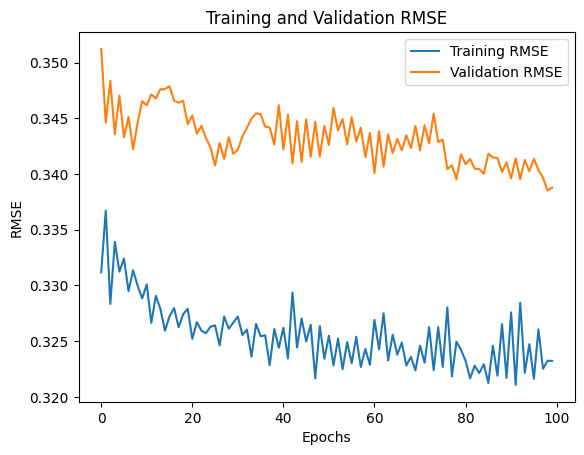

In [94]:
train_rmse = history.history['root_mean_squared_error']
val_rmse = history.history['val_root_mean_squared_error']

# Plot RMSE
plt.plot(train_rmse, label='Training RMSE')
plt.plot(val_rmse, label='Validation RMSE')
plt.title('Training and Validation RMSE')
plt.xlabel('Epochs')
plt.ylabel('RMSE')
plt.legend()
plt.show()


In [100]:
book_df = books_cf

# Mengambil sampel user
# user_id = final_rating['User-ID'].sample(1).iloc[0] # Mengambil sampel User ID secara acak
user_id = int(input("Masukkan User-ID: "))
book_readed_by_user = final_rating[final_rating['User-ID'] == user_id]

# Membuat variabel book_not_readed
book_not_readed = book_df[~book_df['isbn'].isin(book_readed_by_user['ISBN'].values)]['isbn']
book_not_readed = list(
    set(book_not_readed)
    .intersection(set(isbn_to_isbn_encoded.keys()))
)

book_not_readed = [[isbn_to_isbn_encoded.get(x)] for x in book_not_readed]
user_encoder = user_to_user_encoded.get(user_id)
user_book_array = np.hstack(
    ([[user_encoder]] * len(book_not_readed), book_not_readed)
)

Masukkan User-ID: 209516


In [101]:
ratings_model = model.predict(user_book_array).flatten()

top_ratings_indices = ratings_model.argsort()[-10:][::-1]

recommended_book_ids = [
    isbn_encoded_to_isbn.get(book_not_readed[x][0]) for x in top_ratings_indices
]


top_book_user = (
    book_readed_by_user.sort_values(
        by='Book-Rating',
        ascending=False
    )
    .head(10)['ISBN'].values
)

print(top_book_user)

book_df_rows = book_df[book_df['isbn'].isin(top_book_user)]

# Menampilkan hasil rekomendasi buku dalam DataFrame
book_df_rows_data = []
for row in book_df_rows.itertuples():
    book_df_rows_data.append([row.book_title, row.book_author])

recommended_book = book_df[book_df['isbn'].isin(recommended_book_ids)]

recommended_book_data = []
for row in recommended_book.itertuples():
    recommended_book_data.append([row.book_title, row.book_author])

output_columns = ['Book Title', 'Book Author']
df_book_readed_by_user = pd.DataFrame(book_df_rows_data, columns=output_columns)
df_recommended_books = pd.DataFrame(recommended_book_data, columns=output_columns)

4/4 [==============================] - 0s 3ms/step
['0380778556' '0446310786' '0553574574' '0060958022' '0552998486'
 '0375703861' '0060976845' '002542730X' '0553268880' '0140244824']


In [104]:
# Menampilkan hasil rekomendasi
print("Rekomendasi untuk User ID: {}".format(user_id))
print("===" * 9)
print("Buku dengan rating tertinggi yang diberikan oleh User ID{}".format(user_id))
print("----" * 8)
print(df_book_readed_by_user)
print("----" * 8)
print("10 Rekomendasi buku")
print("----" * 8)
df_recommended_books

Rekomendasi untuk User ID: 209516
Buku dengan rating tertinggi yang diberikan oleh User ID209516
--------------------------------
                                          Book Title          Book Author
0  Politically Correct Bedtime Stories: Modern Ta...    James Finn Garner
1                        Five Quarters of the Orange        Joanne Harris
2                  Little Altars Everywhere: A Novel        Rebecca Wells
3  Songs in Ordinary Time (Oprah's Book Club (Pap...  Mary McGarry Morris
--------------------------------
10 Rekomendasi buku
--------------------------------


,Book Title,Book Author
0,Stupid White Men ...and Other Sorry Excuses fo...,Michael Moore
1,Brave New World,Aldous Huxley
2,Riptide,Mickey Friedman
3,I Know This Much Is True,Wally Lamb
4,The Alchemist: A Fable About Following Your Dream,Paulo Coelho
5,Charlotte's Web (Trophy Newbery),E. B. White
6,The Secret Garden,Frances Hodgson Burnett
7,Vanished,Mary McGarry Morris
8,The Girls' Guide to Hunting and Fishing,Melissa Bank
9,About a Boy,Nick Hornby
